# Sample selection




This notebook contains the sample selection from the SLACS and SL2S lenses.
The notebook reads in the relevant information of all the lenses and then applies the selection criteria described in the paper. The outcome is a sub-selected sample that is then been used in other notebooks to perform the hierarchical analysis.

Author: Simon Birrer, Xiangyu Huang

In [1]:
# standard python libraries
import numpy as np
from os.path import dirname, abspath
import os
import copy
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
import yaml
import re 


import matplotlib as mpl

mpl.rcParams['axes.linewidth']=2
mpl.rcParams['xtick.labelsize']=15
mpl.rcParams['ytick.labelsize']=15

# lenstronomy and hierArc classes
from lenstronomy.Util import param_util
from hierarc.Util.distribution_util import PDFSampling

# LoS data of the SL2S sample
from scipy.stats import genextreme
from ExternalLenses.SL2S.kappa_ext import read_kappa

# plotting
from myplots import triangle

# path to data products
path2Analysis = abspath(os.getcwd())
print(path2Analysis)

# This cosmology is used to compute the equivalent SIS velocity dispersion from the Einstein radii of the lenses.
H0 = 70
omega_m = 0.30
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
cosmo = FlatLambdaCDM(H0=H0, Om0=omega_m)


/Users/xiangyuhuang/Documents/phd_research/TDCOSMO_milestone/7LensMilestone/Likelihoods/MilestoneLikelihood


## selection criteria

See detail in Section 5 in TDCOSMO collaboration (2025).

In [2]:
ellipticity_select = True
lensing_info_select = True
sigma_sis_select = True
kin_quality_select = True
kext_select = True 

## load data

In [3]:
# paths to files
path2tdcosmo = 'TDCOSMO_sample'
path2slacs = 'ExternalLenses/SLACS'
path2sl2s = 'ExternalLenses/SL2S'

# line-of-sight kappa distributions
path2kappa_slacs = os.path.join(path2Analysis, path2slacs, 'kappa_ext')
path2kappa_sl2s = os.path.join(path2Analysis, path2sl2s, 'kappa_ext')

# files for all parameters
file_name_slacs = os.path.join(path2Analysis, path2slacs, 'slacs_all_params.csv')
file_name_sl2s = os.path.join(path2Analysis, path2sl2s, 'sl2s_all_params.csv')
file_name_sl2s_new_data = os.path.join(path2Analysis, path2sl2s, 'sl2s_all_params_ws.csv')  # data from new CFHT observations, modeled by William Sheu
file_name_tdcosmo_yaml = os.path.join(path2Analysis, path2tdcosmo, 'tdcosmo_sample.yaml')

# LOS summary statistics
file_name_slacs_los = os.path.join(path2Analysis, path2slacs, 'LineOfSightData.csv')
file_name_sl2s_los_gev = os.path.join(path2kappa_sl2s, 'sl2s_los_gev.csv')



## Select from lens set

In [4]:
# apply selection criteria

NoverRmed_random_slacs = 1.028768  # N/r value from 100000 random patches on the sky with same survey and depth as the lenses

def NoverRmed(name, sample_name):
    """
    reads out the number for N/r weigthing from the DECals data in the table for a specific lens
    """
    if sample_name == 'SLACS':
        with open(file_name_slacs_los, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                if '#name' in row:
                    name_row = row['#name']
                    if name_row == name:
                        return float(row['NoverRmed']) / NoverRmed_random_slacs
        print('lens with name %s not in table for NoverRmed.' % (name))
        return -1
    elif sample_name in ['SL2S', 'SL2S_new_data']:
        with open(file_name_sl2s_los_gev, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                if 'name' in row:
                    name_row = row['name']
                    if name_row == name:
                        return float(row['NoverRmed_med'])
        print('lens with name %s not in table for NoverRmed.' % (name))
        return -1
    elif sample_name == 'TDCOSMO':
        return 0  # we don't have this summary statistics and we just make sure it is selected
        
    
        
def vel_disp(row, sample_name = None):
    """reads out the velocity dispersion and error from the csv file.

    Args:
        row (_type_): row in csv file
        sample_name (_type_, optional): supported: ["SLACS", "SL2S", "SL2S_new_data"]. Defaults to None.

    Returns:
        _type_: sigma_v, sigma_v_error
    """
    if sample_name in ['SL2S', 'SL2S_new_data']:
        try:
            sigma_v = float(row['sigma_v_pritom'])
            sigma_v_error = float(row['sigma_v_error_pritom'])
        except:
            sigma_v = -1
            sigma_v_error = np.inf
        return sigma_v, sigma_v_error
    
    if sample_name == 'SLACS':
        try:
            sigma_v = float(row['sigma_v_kcwi_half_reff'])
            sigma_v_error = float(row['sigma_v_kcwi_half_reff_error'])
        except:
            sigma_v = -1
            sigma_v_error = np.inf 
        return sigma_v, sigma_v_error
    
    if sample_name == 'TDCOSMO':
        name = row['name']
        if name in ['B1608+656', 'HE0435-1223', 'SDSS1206+4332', 'WFI2033-4723', 'PG1115+080']:
            sigma_v = float(row['JWST_NIRSpec']['sigma_v'])
            sigma_v_error = float(row['JWST_NIRSpec']['sigma_v_error'])
            return sigma_v, sigma_v_error
        elif name in ['DES0408-5354', 'WGD2038-4008']:
            sigma_v = float(row['MUSE']['sigma_v'])
            sigma_v_error = float(row['MUSE']['sigma_v_error'])
            return sigma_v, sigma_v_error
        elif name in ['RXJ1131-1231']:
            sigma_v = float(row['JWST_NIRSpec']['sigma_v'])
            sigma_v_error = float(row['JWST_NIRSpec']['sigma_v_error'])
            return sigma_v, sigma_v_error
      
    return -1, np.inf


def light_ellipticity(row):
    """
    computes the light ellipticity from the row in the table. This function can deal with single, double and triple Sersic profiles
    """

    name = row['name']
    if name == 'RXJ1131-1231':
        row = row['light_profile_F814W'] # RXJ1131-1231 has multiple light profiles
    try:
        light_model = str(row['light_model'])
        add = ''
    except:
        try:
            light_model = str(row['light_model_CFHT'])
            add = '_CFHT'
        except KeyError:
            light_model = ''
    if name == 'WGD2038-4008':
        light_model = 'triple_sersic' # WGD2038-4008 has a triple Sersic light profile
        
    
    if light_model == 'single_sersic':
        e1, e2 = float(row['e1_sersic1'+add]), float(row['e2_sersic1'+add])
        
    elif light_model == 'double_sersic':
        r_sersic_1, n_sersic_1, e1_sersic1, e2_sersic1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['e1_sersic1']), float(row['e2_sersic1']), float(row['amp_sersic_1'])
        r_sersic_2, n_sersic_2, e1_sersic2, e2_sersic2, amp_sersic_2 = float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['e1_sersic2']), float(row['e2_sersic2']), float(row['amp_sersic_2'])
        from lenstronomy.LightModel.light_model import LightModel
        lightModelClass = LightModel(light_model_list=['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE'])
        from lenstronomy.Analysis.light_profile import LightProfileAnalysis
        lightAnalysis = LightProfileAnalysis(lightModelClass)
        kwargs_light = [{'amp': amp_sersic_1, 'R_sersic': r_sersic_1, 'n_sersic': n_sersic_1, 'e1': e1_sersic1, 'e2': e2_sersic1, 'center_x': 0, 'center_y': 0},
                        {'amp': amp_sersic_2, 'R_sersic': r_sersic_2, 'n_sersic': n_sersic_2, 'e1': e1_sersic2, 'e2': e2_sersic2, 'center_x': 0, 'center_y': 0}]
        e1, e2 = lightAnalysis.ellipticity(kwargs_light, grid_spacing=0.1, grid_num=100)
    
    elif light_model == 'triple_sersic':
        r_sersic_1, n_sersic_1, e1_sersic1, e2_sersic1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['e1_sersic1']), float(row['e2_sersic1']), float(row['amp_sersic_1'])
        r_sersic_2, n_sersic_2, e1_sersic2, e2_sersic2, amp_sersic_2 = float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['e1_sersic2']), float(row['e2_sersic2']), float(row['amp_sersic_2'])
        r_sersic_3, n_sersic_3, e1_sersic3, e2_sersic3, amp_sersic_3 = float(row['r_sersic_3']), float(row['n_sersic_3']), float(row['e1_sersic3']), float(row['e2_sersic3']), float(row['amp_sersic_3'])
        from lenstronomy.LightModel.light_model import LightModel
        lightModelClass = LightModel(light_model_list=['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE', 'SERSIC_ELLIPSE'])
        from lenstronomy.Analysis.light_profile import LightProfileAnalysis
        lightAnalysis = LightProfileAnalysis(lightModelClass)
        kwargs_light = [{'amp': amp_sersic_1, 'R_sersic': r_sersic_1, 'n_sersic': n_sersic_1, 'e1': e1_sersic1, 'e2': e2_sersic1, 'center_x': 0, 'center_y': 0},
                        {'amp': amp_sersic_2, 'R_sersic': r_sersic_2, 'n_sersic': n_sersic_2, 'e1': e1_sersic2, 'e2': e2_sersic2, 'center_x': 0, 'center_y': 0},
                        {'amp': amp_sersic_3, 'R_sersic': r_sersic_3, 'n_sersic': n_sersic_3, 'e1': e1_sersic3, 'e2': e2_sersic3, 'center_x': 0, 'center_y': 0}]
        e1, e2 = lightAnalysis.ellipticity(kwargs_light, grid_spacing=0.1, grid_num=100)
    else:
        e1, e2 = 0, 0
    phi, q = param_util.ellipticity2phi_q(e1, e2)
    return q


def lensing_information(row, sample_name):
    """access lensing information from data table

    Args:
        row (_type_): a row in a csv file
        sample_name (_type_): in ['SLACS', 'SL2S', 'SL2S_new_data', 'TDCOSMO]

    Returns:
        _type_: lensing information
    """
    lensing_info_flag = 1
    if sample_name in ['SLACS', 'SL2S']:
        return lensing_info_flag, float(row['lensing_information_dinosii'])
    if sample_name == 'SL2S_new_data':
        return lensing_info_flag, float(row['lensing_information'])
    if sample_name == 'TDCOSMO':
        lensing_info_flag = 0
        return lensing_info_flag, np.nan

In [5]:
def select_lens_set(sample_name, kwargs_select):
    """
    loops through the lenses and applies a gigantic AND operation based on the different selection criteria.
    Returns key quantities of the selected lenses in a list:
    [z_lens, z_source, sigma_v, r_eff, theta_E, r_eff/theta_E, gamma, sigma_v_SIS, nR_med, q_light, lensing_info]
    """
    lens_list = []
    name_list = []
    if sample_name == 'SLACS':
        file_name = file_name_slacs
    elif sample_name == 'SL2S':
        file_name = file_name_sl2s
    elif sample_name == 'SL2S_new_data':
        file_name = file_name_sl2s_new_data
    elif sample_name == 'TDCOSMO':
        file_name = file_name_tdcosmo_yaml

    if sample_name in ['SLACS', 'SL2S', 'SL2S_new_data']:
        with open(file_name, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                param, name, bool_select = select_lens(row, sample_name, **kwargs_select)
                if bool_select:
                    lens_list.append(param)
                    name_list.append(name)
    elif sample_name == 'TDCOSMO':
        with open(file_name, 'r') as myFile:
            tdcosmo_yaml = yaml.safe_load(myFile)
            for name in tdcosmo_yaml.keys():
                row = tdcosmo_yaml[name]
                row['name'] = name
                param, name, bool_select = select_lens(row, sample_name, **kwargs_select)
                if bool_select:
                    lens_list.append(param)
                    name_list.append(name)
        
    return name_list, lens_list
            


def select_lens(row, sample_name, ifu_select=False, imaging_flag_select=True, without_quality_imaging=False,
                  exclude_ifu=False, z_lens_min=0, 
                  sigma_v_min=100, sigma_v_max=400, q_light_min=0.7,
                  r_eff2theta_E_max=20, NoverRmed_max=1.78, verbose=False, lensing_info_min = 30, kin_snr_select=False):
    """
    loops through the lenses and applies a gigantic AND operation based on the different selection criteria.
    Returns key quantities of the selected lenses in a list:
    z_lens, z_source, sigma_v, r_eff, theta_E, gamma
    
    :param without_quality_imaging: if imaging_flag_select = False ignores the imaging_flag=1 objects 
    
    """

    name = row['name']
    try:
        theta_E = float(row['theta_E'])
        z_lens = float(row['z_lens'])
        z_source = float(row['z_source'])
    except:
        if verbose:
            print('%s has not complete parameters' % name)
        return None, name, False
    try:
        r_eff = float(row['r_eff'])
    except:
        if 'r_eff_hernquist' in row:
            r_eff = float(row['r_eff_hernquist'])  # Hernquist fit r_eff for SLACS
            print('chose Hernquist half-light radius')
        elif 'r_sersic1_CFHT' in row:
            r_eff = float(row['r_sersic1_CFHT'])
        else:
            return None, name, False
            
    
    imaging_flag = float(row.get('flag_imaging_tan23', 1))
    perturber_flag = float(row.get('perturber_flag', 1))
    
    if sample_name in ['SL2S', 'SL2S_new_data']:
        try:
            kin_snr = float(row['snr_pritom'])
        except:
            kin_snr = 0.
    elif sample_name in ['SLACS', 'TDCOSMO']:
        kin_snr = 100 # we do not select on SNR for KCWI and TDCOSMO lenses; we do not use SLACS lenses with only SDSS spectra


    if imaging_flag == 1:
        gamma = float(row['gamma'])
        try:
            gamma_error = float(row['gamma_error'])
        except:
            gamma_error_stat = float(row['gamma_error_stat'])
            gamma_error_sys = float(row['gamma_error_sys'])
            gamma_error = np.hypot(gamma_error_stat, gamma_error_sys)
    else:
        gamma = -1  # we need power-law lens models
        gamma_error = np.inf
    
    nR_med = NoverRmed(name, sample_name)


    sigma_v, sigma_v_error = vel_disp(row, sample_name=sample_name)

    lensCosmo = LensCosmo(float(row['z_lens']), float(row['z_source']), cosmo=cosmo)
    sigma_v_SIS = lensCosmo.sis_theta_E2sigma_v(theta_E)

    q_light = light_ellipticity(row)
    
    lensing_info_flag, lensing_info = lensing_information(row, sample_name)
    param = np.array([z_lens, z_source, sigma_v, r_eff, theta_E, r_eff/theta_E, gamma, sigma_v_SIS, nR_med, q_light, lensing_info]) #, nR_med])  # , sigma_v_predict/sigma_v


    if perturber_flag < 1 and 0 < nR_med < NoverRmed_max:
        if verbose:
            print('lens %s has perturber nearby but meets the NoverRmed criteria <%s with %s' % (name, NoverRmed_max, nR_med))
    if perturber_flag < 1:
        if verbose:
            print('%s not selected due to perturber flag' % name)
        return param, name, False
    if not (0 <= nR_med < NoverRmed_max):
        if verbose:
            print('%s not selected due to overdensity %s' % (name, nR_med))
        return param, name, False
    if q_light < q_light_min:
        if verbose:
            print('%s not selected due to high light ellipticity' % name)
        return param, name, False
    if imaging_flag_select and imaging_flag < 1:
        if verbose:
            print('%s not selected due to imaging flag' % name)
        return param, name, False
    if not imaging_flag_select and without_quality_imaging:
        if imaging_flag >= 1 or imaging_flag < 0:
            if verbose:
                print('%s not selected due to imaging flag' % name)
            return param, name, False
    
    if sigma_v_SIS > sigma_v_max or sigma_v_SIS < sigma_v_min:
        if verbose:
            print('%s not selected due to SIS velocity dispersion %s' % (name, sigma_v_SIS))
        return param, name, False
    
    if z_lens < z_lens_min:
        if verbose:
            print('%s not selected due to lens redshift %s below minimum %s' % (name, z_lens, z_lens_min))
        return param, name, False
        
    if 'flag_ifu_kcwi' in row:
        try:
            ifu_flag = float(row['flag_ifu_kcwi'])
        except:
            ifu_flag = 0
    else:
        ifu_flag = 0

    if ifu_select: 
        if ifu_flag < 1:
            # not an IFU lens when IFU is required
            return param, name, False
    if exclude_ifu:
        if ifu_flag == 1:
            # an IFU lens when there is no IFU lens required
            return param, name, False
        
    if kin_snr_select:
        if kin_snr < 10.: 
            if verbose:
                print('%s not selected due to low SNR in spectra' % name)
            return param, name, False
      
    if r_eff/theta_E > r_eff2theta_E_max:
        if verbose:
            print('%s not selected due to r_eff/theta_E %s' % (name, r_eff/theta_E))
        return param, name, False

    if sigma_v < 50:
        if verbose:
            print('%s not selected due to measured velocity dispersion %s' % (name, sigma_v))
        return param, name, False
    
    if lensing_info_flag == 1 and lensing_info < lensing_info_min:
        if verbose:
            print('%s not selected due to lensing information %s' % (name, lensing_info))
        return param, name, False

    return param, name, True



In [6]:
q_light_min = 0.7 if ellipticity_select else 0.0
(sigma_v_min, sigma_v_max) = (150, 350) if sigma_sis_select else (0, 2000)
NoverRmed_max = 2.10 if kext_select else 1000

kwargs_select_always = {'z_lens_min':0, 'sigma_v_min':sigma_v_min, 'sigma_v_max':sigma_v_max, 'r_eff2theta_E_max': 20, 'NoverRmed_max': NoverRmed_max, 'q_light_min': q_light_min}

### TDCOSMO sample

In [7]:
kwargs_select_tdcosmo = {**kwargs_select_always, **{'ifu_select': False, 'imaging_flag_select':True, 'exclude_ifu': False, 'kin_snr_select': False, 'verbose': True}}

name_list_tdcosmo, tdcosmo_sample = select_lens_set(sample_name='TDCOSMO', kwargs_select=kwargs_select_tdcosmo)
print('TDCOSMO: ', name_list_tdcosmo, len(name_list_tdcosmo))

TDCOSMO:  ['B1608+656', 'DES0408-5354', 'HE0435-1223', 'PG1115+080', 'RXJ1131-1231', 'SDSS1206+4332', 'WFI2033-4723', 'WGD2038-4008'] 8


### SLACS sample with KCWI IFU spectra

In [8]:
kwargs_select_kcwi = {**kwargs_select_always, **{'ifu_select': True, 'imaging_flag_select':True, 'exclude_ifu': False, 'verbose': True, 'kin_snr_select': False}}

name_list_slacs_ifu_quality, slacs_ifu_sample_quality = select_lens_set(sample_name='SLACS', kwargs_select=kwargs_select_kcwi)
print('SLACS KCWI: ', name_list_slacs_ifu_quality, len(name_list_slacs_ifu_quality))

SDSSJ0044+0113 has not complete parameters
SDSSJ0216-0813 has not complete parameters
lens SDSSJ0252+0039 has perturber nearby but meets the NoverRmed criteria <2.1 with 1.2555269992845814
SDSSJ0252+0039 not selected due to perturber flag
SDSSJ0737+3216 not selected due to perturber flag
lens SDSSJ0819+4534 has perturber nearby but meets the NoverRmed criteria <2.1 with 1.3295213303679743
SDSSJ0819+4534 not selected due to perturber flag
SDSSJ0903+4116 not selected due to perturber flag
SDSSJ0912+0029 not selected due to high light ellipticity
SDSSJ0935-0003 has not complete parameters
lens SDSSJ0936+0913 has perturber nearby but meets the NoverRmed criteria <2.1 with 1.4651320803135404
SDSSJ0936+0913 not selected due to perturber flag
SDSSJ0959+4416 has not complete parameters
SDSSJ1016+3859 has not complete parameters
SDSSJ1020+1122 has not complete parameters
SDSSJ1100+5329 not selected due to overdensity 2.355545662384522
SDSSJ1142+1001 has not complete parameters
SDSSJ1143-0144 ha

### SL2S sample

In [9]:
lensing_info_min = 150 if lensing_info_select else 0

kwargs_select_sl2s = {**kwargs_select_always, **{'ifu_select': False, 'imaging_flag_select':True, 'exclude_ifu': False, 'verbose': True, 'kin_snr_select': kin_quality_select, 'lensing_info_min': lensing_info_min}}
del kwargs_select_sl2s['NoverRmed_max'] # remove the selection on NoverRmed_max for SL2S lenses

name_list_sl2s_quality, sl2s_sample_quality = select_lens_set(sample_name='SL2S', kwargs_select=kwargs_select_sl2s)
print('SL2S: ', name_list_sl2s_quality, len(name_list_sl2s_quality))

name_list_sl2s_new_quality, sl2s_new_sample_quality = select_lens_set(sample_name='SL2S_new_data', kwargs_select=kwargs_select_sl2s)
print('SL2S new data: ', name_list_sl2s_new_quality, len(name_list_sl2s_new_quality))

# for the lenses selected from dinos 1 paper, require that it is not in the new data sample
name_list_sl2s_no_selection = select_lens_set(sample_name='SL2S_new_data', kwargs_select={'ifu_select':False, 'imaging_flag_select':True, 'without_quality_imaging':False,
                  'exclude_ifu':False, 'z_lens_min':0, 
                  'sigma_v_min':0, 'sigma_v_max':2000, 'q_light_min':0.0,
                  'r_eff2theta_E_max':20, 'NoverRmed_max':100, 'verbose':False, 'lensing_info_min':0., 'kin_snr_select':False})[0]

sl2s_sample_quality = [sl2s_sample_quality[i] for i, name in enumerate(name_list_sl2s_quality) if name not in name_list_sl2s_no_selection]
name_list_sl2s_quality = [name for name in name_list_sl2s_quality if name not in name_list_sl2s_no_selection]
print('SL2S lens selected from dinos 1 paper: ', name_list_sl2s_quality, len(name_list_sl2s_quality))

name_list_sl2s_quality_all = name_list_sl2s_new_quality + name_list_sl2s_quality
sl2s_sample_quality_all = sl2s_new_sample_quality + sl2s_sample_quality


print('SL2S all: ', name_list_sl2s_quality_all, len(name_list_sl2s_quality_all))

SL2SJ0208-0714 has not complete parameters
SL2SJ0213-0743 has not complete parameters
SL2SJ0214-0405 not selected due to lensing information 62.87693865218512
SL2SJ0217-0513 not selected due to low SNR in spectra
SL2SJ0219-0829 not selected due to lensing information 45.77620872826516
SL2SJ0223-0651 has not complete parameters
SL2SJ0225-0454 not selected due to high light ellipticity
SL2SJ0226-0406 has not complete parameters
SL2SJ0226-0420 not selected due to lensing information 62.60002110816651
SL2SJ0232-0408 not selected due to lensing information 54.46351432849459
lens with name SL2SJ0849-0251 not in table for NoverRmed.
SL2SJ0849-0251 not selected due to overdensity -1
SL2SJ0849-0412 not selected due to high light ellipticity
SL2SJ0858-0143 has not complete parameters
SL2SJ0901-0259 not selected due to low SNR in spectra
SL2SJ0904-0059 not selected due to lensing information 115.50780907587276
lens with name SL2SJ0959+0206 not in table for NoverRmed.
SL2SJ0959+0206 not selected d

## power-law slope distributions
Here we calculate the mean and spread in the intrinsic power-law mass slope distributions from the well-modelled subset of the individual samples (SLACS and SL2S)

In [10]:
def gamma_distribution(file_name, sample_names, yaml_file = False):
    """
    computes the sample mean in the power-law slope, the uncertainty in the mean and the spread
    """
    num_sample = len(sample_names)
    gamma_mean_list = []
    gamma_sigma_list = []
    gamma_name_list = []
    if yaml_file:
        with open(file_name, 'r') as myFile:
            tdcosmo_yaml = yaml.safe_load(myFile)
            for name in sample_names:
                row = tdcosmo_yaml[name]
                gamma_mean_list.append(float(row['gamma']))
                try:
                    gamma_sigma_list.append(float(row['gamma_error']))
                except:
                    gamma_sigma_list.append(np.hypot(float(row['gamma_error_sys']), float(row['gamma_error_stat'])))
                gamma_name_list.append(name)
    else:   
        with open(file_name, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                name = row['name']
                if name in sample_names:
                    gamma_mean_list.append(float(row['gamma']))
                    try:
                        gamma_sigma_list.append(float(row['gamma_error']))
                    except:
                        gamma_sigma_list.append(np.hypot(float(row['gamma_error_sys']), float(row['gamma_error_stat'])))
                    gamma_name_list.append(name)
    gamma_mean_list = np.array(gamma_mean_list)
    gamma_sigma_list = np.array(gamma_sigma_list)
                
    gamma_mean = np.sum(gamma_mean_list / gamma_sigma_list**2) / np.sum(1./ gamma_sigma_list**2)
    gamma_mean_sigma = np.sqrt(1 / np.sum(1./ gamma_sigma_list**2)) * num_sample / (num_sample - 1)
    gamma_sigma = np.std(gamma_mean_list)
    return gamma_mean, gamma_mean_sigma, gamma_sigma, gamma_mean_list, gamma_sigma_list, gamma_name_list


def plot_gamma(sample_name, kwargs_select):

    name_list, _ = select_lens_set(sample_name=sample_name, kwargs_select=kwargs_select)
    
    if sample_name == 'SLACS':
        file_name = file_name_slacs
        yaml_file = False
    elif sample_name == 'SL2S':
        file_name = file_name_sl2s
        yaml_file = False
    elif sample_name == 'SL2S_new_data':
        file_name = file_name_sl2s_new_data
        yaml_file = False
    elif sample_name == 'TDCOSMO':
        file_name = file_name_tdcosmo_yaml
        yaml_file = True

    gamma_mean, gamma_mean_sigma, gamma_sigma, gamma_mean_list, gamma_sigma_list, gamma_name_list = gamma_distribution(file_name, name_list, yaml_file=yaml_file)

    print(r'mean $\gamma_{\rm pl}$: ', gamma_mean)
    print('error in mean: ', gamma_mean_sigma)
    print('1-sigma distribution width: ', gamma_sigma)

    title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
    fmt = "{{0:{0}}}".format(".2f").format

    txt = r'$\gamma_{\rm pl}: $' + title.format(fmt(gamma_mean), fmt(gamma_sigma), fmt(gamma_sigma))

    f, ax = plt.subplots(1, 1, figsize=(len(gamma_mean_list)/2, 4))
    ax.errorbar(np.arange(len(gamma_mean_list)), gamma_mean_list, yerr=gamma_sigma_list, xerr=None, fmt='o', ecolor=None, elinewidth=None,
                capsize=None, barsabove=False, lolims=False, uplims=False,
                xlolims=False, xuplims=False, errorevery=1, capthick=None, data=None, label=None)
    ax.set_xticks(ticks=np.arange(len(gamma_mean_list)))
    ax.set_xticklabels(labels=gamma_name_list, rotation='vertical')
    ax.set_ylabel(r'$\gamma_{\rm pl}$', fontsize=15)
    ax.hlines(gamma_mean, xmin=-1, xmax=len(gamma_mean_list), colors='k', linestyles='--')
    ax.fill_between([-1, len(gamma_mean_list)], gamma_mean - gamma_sigma, gamma_mean + gamma_sigma, alpha=0.2)
    ax.set_xlim([-0.5, len(gamma_mean_list)-0.5])
    ax.text(0.5, 0.9, txt, fontsize=15, transform = ax.transAxes, ha = 'center')
    plt.title(sample_name, fontsize = 16)
    # plt.tight_layout()

    plt.show()

mean $\gamma_{\rm pl}$:  2.041885858943618
error in mean:  0.031437079674397
1-sigma distribution width:  0.2729670262969126


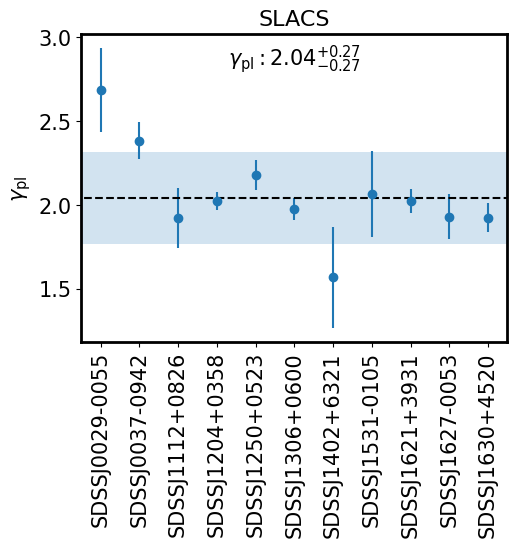

lens with name SL2SJ0205-0930 not in table for NoverRmed.
lens with name SL2SJ0959+0206 not in table for NoverRmed.
mean $\gamma_{\rm pl}$:  2.132083693325744
error in mean:  0.08511622189070879
1-sigma distribution width:  0.10006870406932591


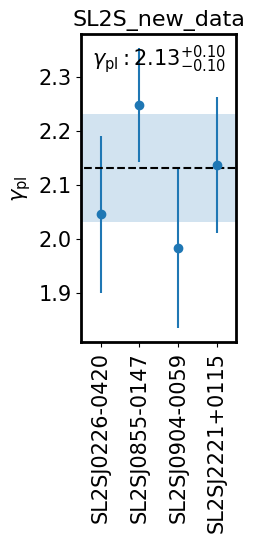

mean $\gamma_{\rm pl}$:  2.0417293997965413
error in mean:  0.010935444550448517
1-sigma distribution width:  0.1328003670928661


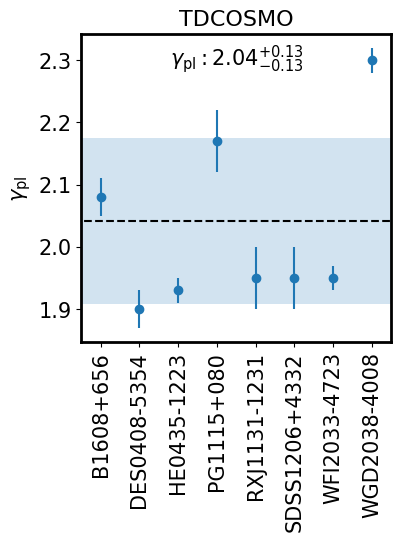

In [11]:
kwargs_select_kcwi['verbose'] = False
plot_gamma(sample_name='SLACS', kwargs_select=kwargs_select_kcwi)

# plot_gamma(sample_name='SL2S', kwargs_select={**{'ifu_select': False, 'imaging_flag_select':True, 'exclude_ifu': False, 'kin_snr_select': True, 'lensing_info_min': 150}, **kwargs_select_always})

kwargs_select_sl2s['verbose'] = False
plot_gamma(sample_name='SL2S_new_data', kwargs_select=kwargs_select_sl2s)

plot_gamma(sample_name='TDCOSMO', kwargs_select=kwargs_select_tdcosmo)

## plot the properties of the selected lenses

/var/folders/r1/1npt_dcs5vb2lf_h7h64vh840000gn/T/ipykernel_76840/2225507041.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


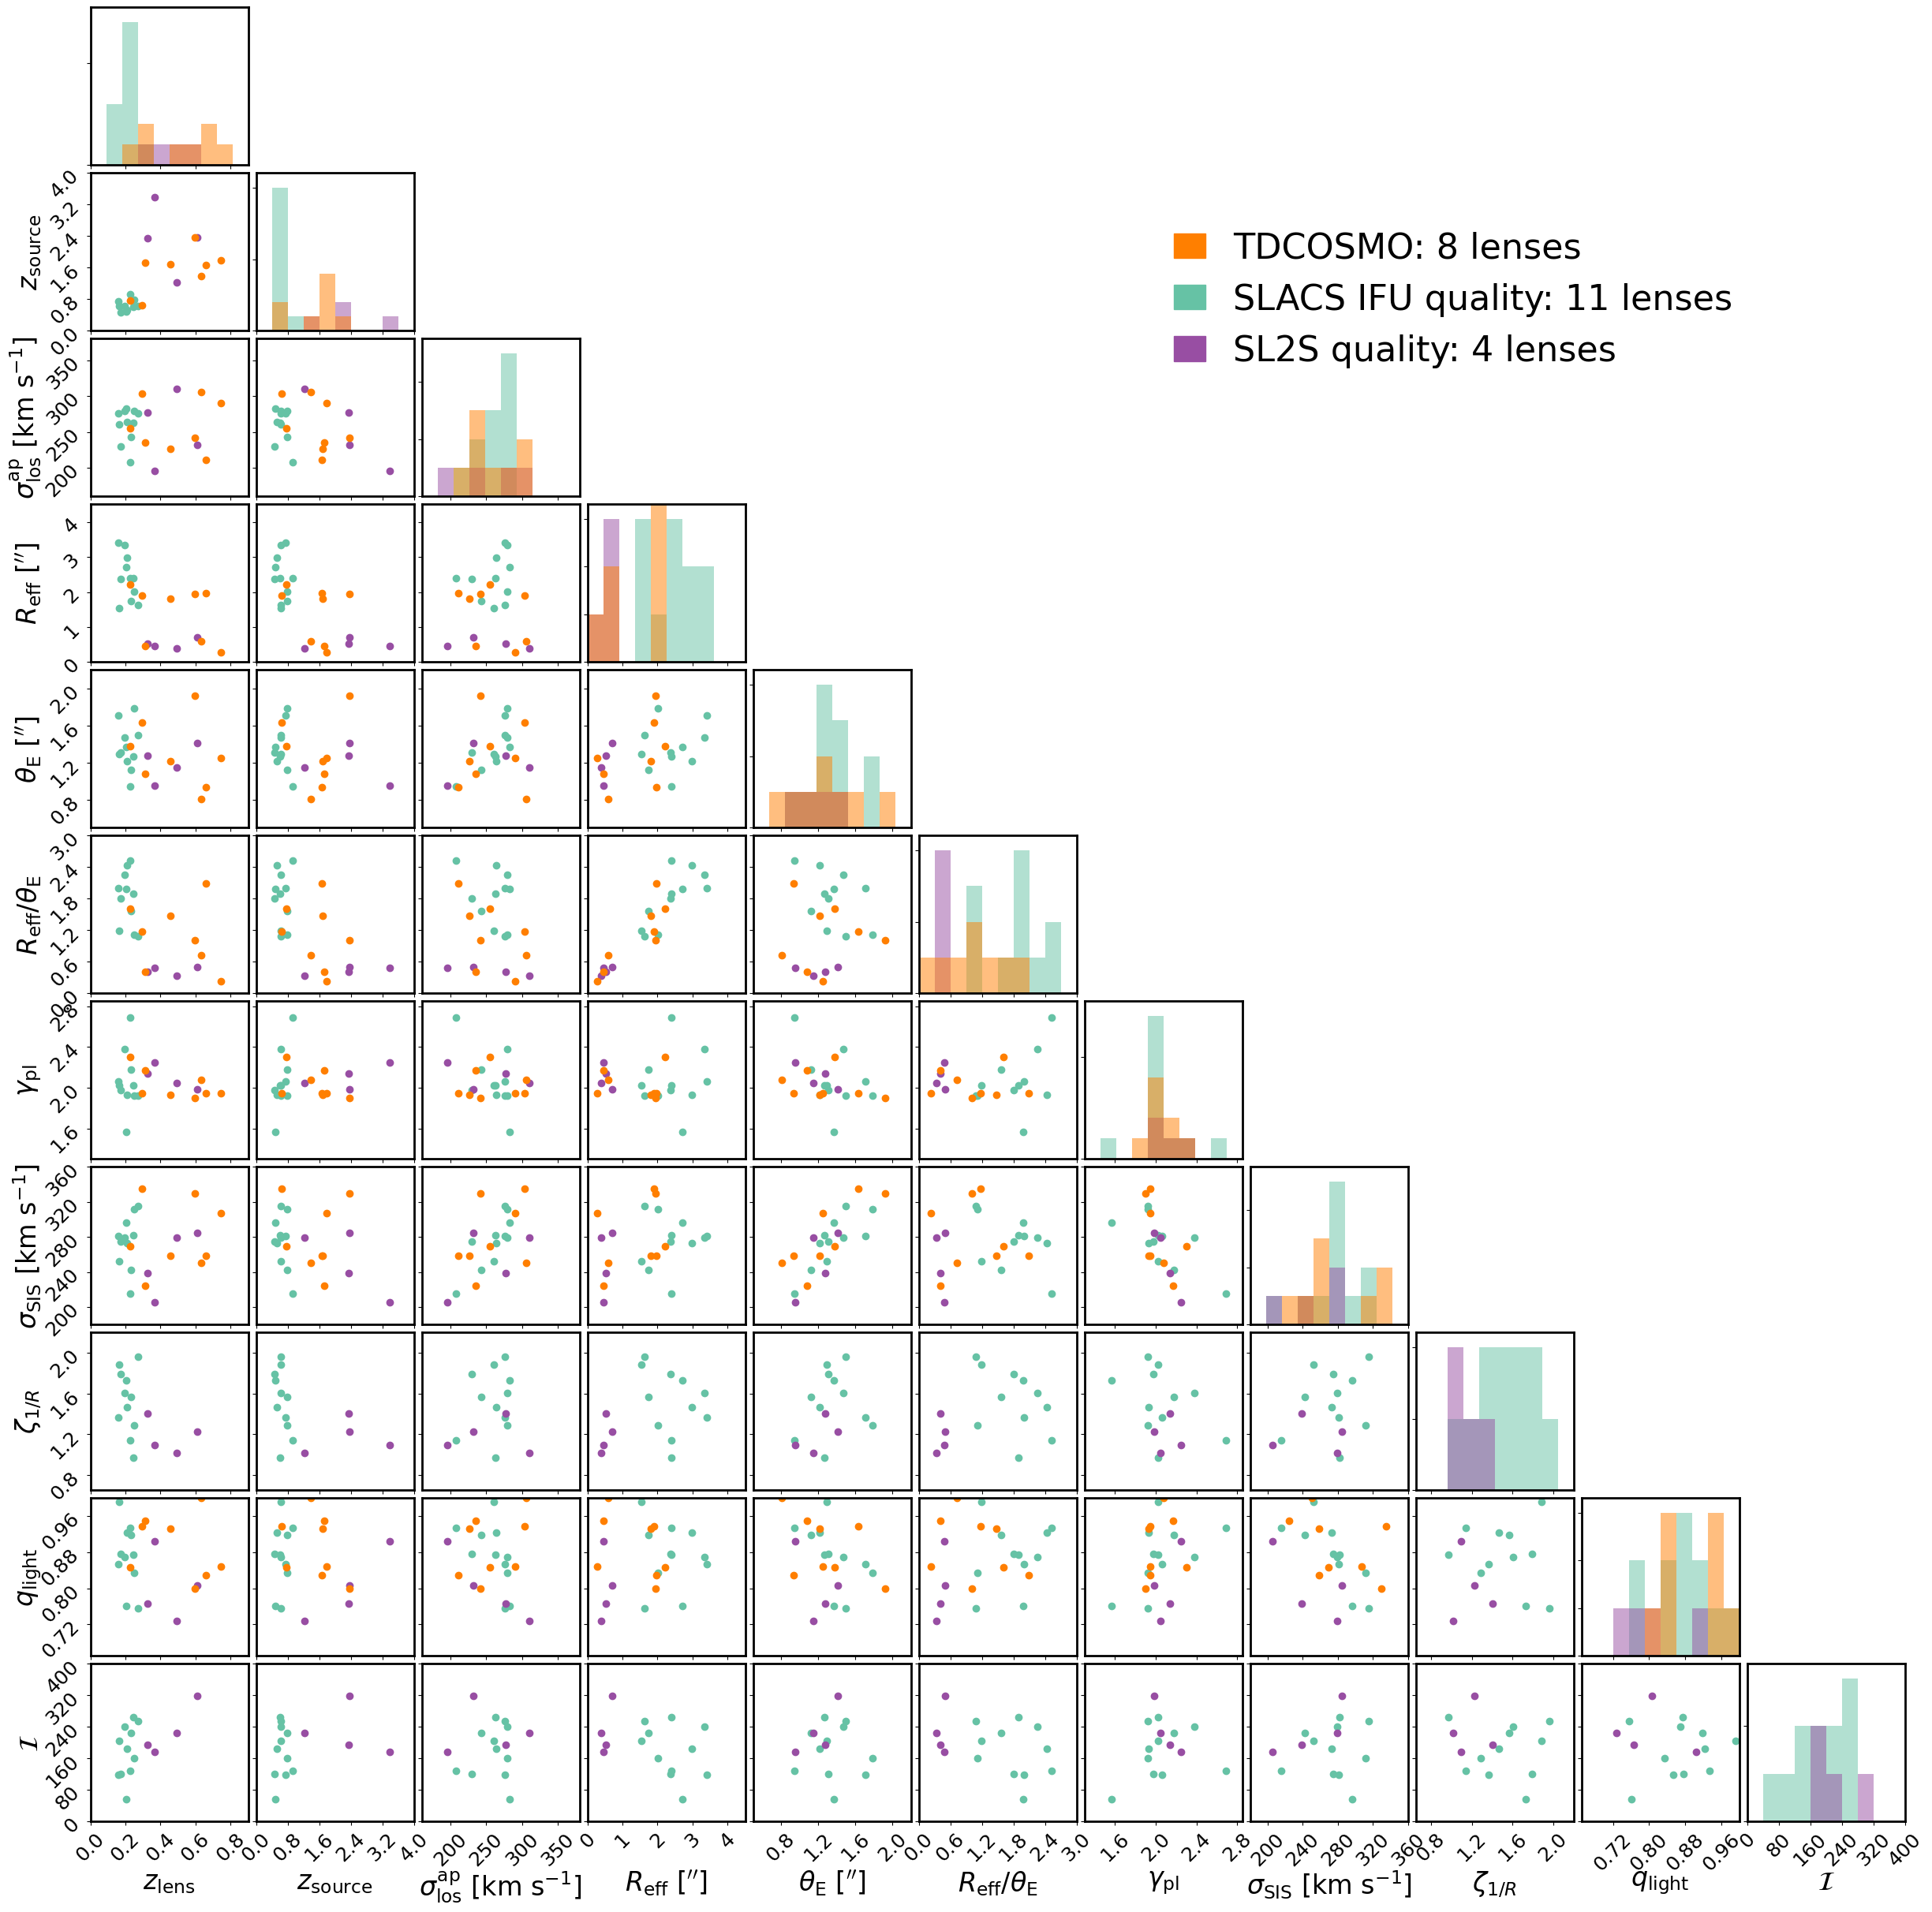

In [12]:
# and here we plot the different samples, as in the paper.

# myplots is a derivative of the corner library that I host on my github repo: https://github.com/sibirrer/myplots
color_list = ['#66c2a5', '#984ea3', '#ff7f00']
color_kcwi, color_sl2s, color_tdcosmo = color_list


labels = [r"$z_{\rm lens}$", r"$z_{\rm source}$", r"$\sigma^{\rm {ap}}_{\rm los}$ [km s$^{-1}$]", r'$R_{\rm eff}$ [${}^{\prime\prime}$]', r'$\theta_{\rm E}$ [${}^{\prime\prime}$]', 
          r'$R_{\rm eff}/\theta_{\rm E} $', r"$\gamma_{\rm pl}$", r"$\sigma_{\rm SIS}$ [km s$^{-1}$]", r"$\zeta_{1/R}$", r"$q_{\rm light}$", r"$\mathcal{I}$"]
extents = [[0, 0.9], [0., 4], [160, 380], [0., 4.5], [0.5, 2.2], [0, 3], [1.3, 2.85], [180, 360], [0.65, 2.2], [0.65, 1], [0, 400]]


fig, axes = triangle.corner_multi(xs_list=[slacs_ifu_sample_quality, sl2s_sample_quality_all, tdcosmo_sample], 
                      weights_list=None, labels=labels, fontsize=24, show_titles=False, title_fmt=".2f",
           title_args={}, extents=extents, truths=None, truth_color="#4682b4",
           scale_hist=False, quantiles=[], verbose=False, dots=None, hist1d_bool=True,
                 scatter_plot=True, kwargs_scatter={'marker': 'o', 'linestyle': ''},
                 cmap_list=["Blues", "Greens", "Oranges", "Reds", "BuPu", "binary"],
                 line_style_list = ['solid', 'solid', 'solid'],
                 color_list=color_list,
                 kwargs_hist2d={}, kwargs_hist1d={'linewidth': 3, 'density': False, 'histtype': "bar", 'alpha': 0.5, 'bins': 10})


ax = axes[0,4]
ax.set_visible(True)
ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

for ax in axes.flat:
    ax.tick_params(labelsize=18)

patch = []
patch.append(mpatches.Patch(color=color_tdcosmo, label='TDCOSMO: ' + str(len(tdcosmo_sample)) + ' lenses'))
patch.append(mpatches.Patch(color=color_kcwi, label='SLACS IFU quality: ' + str(len(slacs_ifu_sample_quality)) + ' lenses'))
patch.append(mpatches.Patch(color=color_sl2s, label='SL2S quality: ' + str(len(sl2s_sample_quality_all)) + ' lenses'))

fig.legend(handles=patch, fontsize=32, handlelength=0.9, loc=[0.6, 0.8], frameon=False)
# fig.savefig('./sample_selection.pdf', bbox_inches='tight')
fig.show()



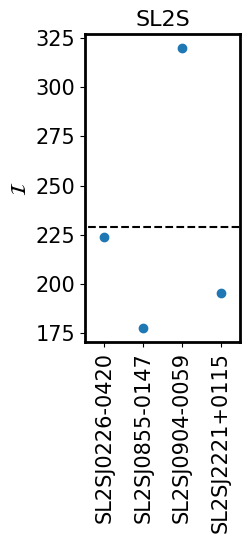

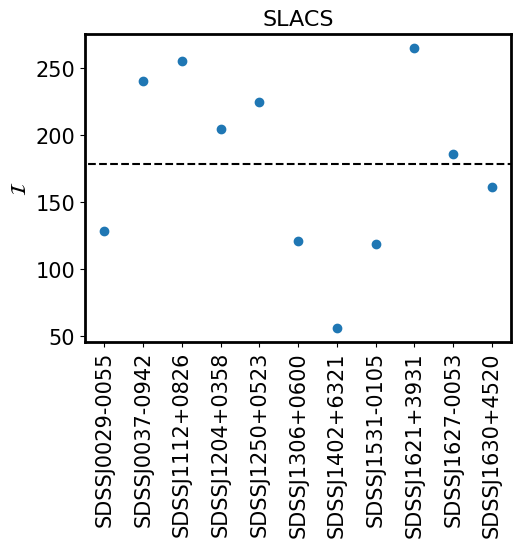

In [13]:
def plot_var(name_list, var_list, var_name = None, sample_name = None):
    """plot specified parameters for selected lenses

    Args:
        name_list (_type_): list of lens names
        var_list (_type_): properties of selected lenses returned by select_lens(...) function
        var_name (_type_, optional): name of the parameter being plotted. Defaults to None.
        sample_name (_type_, optional): sample name. Defaults to None.
    """
    f, ax = plt.subplots(1, 1, figsize=(len(name_list)/2, 4))
    ax.plot(np.arange(len(name_list)), var_list , marker='o', ls = ' ')
    ax.set_xticks(ticks=np.arange(len(name_list)))
    ax.set_xticklabels(labels=name_list, rotation='vertical')
    ax.set_ylabel(var_name, fontsize=15)
    ax.hlines(np.mean(var_list), xmin=-1, xmax=len(name_list), colors='k', linestyles='--')
    ax.set_xlim([-0.5, len(name_list)-0.5])
    # ax.text(0.5, 0.9, txt, fontsize=15, transform = ax.transAxes, ha = 'center')
    plt.title(sample_name, fontsize = 16)
    plt.show()

var_ind = -1 # index of the variable in the parameter_list returned by select_lens(...) function

plot_var(name_list_sl2s_quality_all, [x[var_ind] for x in sl2s_sample_quality_all], var_name=labels[var_ind], sample_name='SL2S')
plot_var(name_list_slacs_ifu_quality, [x[var_ind] for x in slacs_ifu_sample_quality], var_name=labels[var_ind], sample_name='SLACS')


## LOS convergence distributions

In [14]:
# SL2S kappa_ext_distributions
sl2s_kappa_ext = read_kappa.load_sl2s_lenses()

def kappa_distribution(lenses_selected, sample_name, plot = True, fig = None, color_individual = 'grey', color_pop = 'k', set_title = False):
    """read out the kappa_ext distribution from data file

    Args:
        lens_name_list (_type_): list of lens names 
        sample_name (_type_): lens sample name, "SL2S" or "SLACS"

    Returns:
        _type_: lens name list with external kappa distribution
        _type_: external kappa distribution
    """

    percentiles = [16, 50, 84]
    title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
    fmt = "{{0:{0}}}".format(".3f").format

    if sample_name == 'SLACS':
        kappa_choice_ending = '_computed_1innermask_nobeta_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_23.0_med_increments2_2_emptymsk.cat'
        kappa_bins = np.linspace(-0.05, 0.2, 50)
        kappa_pdf_tot = np.zeros(len(kappa_bins)-1)
    elif sample_name == 'SL2S':
        df_sl2s_los_gev = os.path.join(path2kappa_sl2s, 'sl2s_los_gev.csv')
        df_sl2s_los_gev = pd.read_csv(df_sl2s_los_gev) # read in sl2s los data with GEV fit
        log_sigma_kappa_ext = df_sl2s_los_gev['log_sigma_kext'].values
        xi_kappa_ext = df_sl2s_los_gev['xi_kext'].values
        mu_kappa_ext = df_sl2s_los_gev['mu_kext'].values
        name_gev_los = list(df_sl2s_los_gev['name'].values)
        kappa_pdf_tot = np.zeros(200)
        kappa_bins = np.linspace(-0.2, 0.4, 201)

    # loop through selected lenses
    name_list = []
    kappa_mean_list = []
    

    if plot:
        if fig is None:
            fig, ax = plt.subplots(1, 1)
            ax.set_xlim([-0.1, 0.2])
        else:
            ax = fig.gca()
        
        
    for name in lenses_selected:
        bool_sample = False
        if sample_name == 'SLACS':
            try:
                filepath = os.path.join(path2kappa_slacs, 'kappahist_'+name+kappa_choice_ending)
                output = np.loadtxt(filepath, delimiter=' ', skiprows=1)
                kappa_sample = output[:, 0]
                kappa_weights = output[:, 1]
                kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=kappa_bins, density=True)
                bool_sample = True
            except:
                print('lens %s does not have a kappa_ext file %s' % (name, filepath))
        elif sample_name == 'SL2S':
            if name in name_gev_los: # if no sampled kappa_ext, use gev fit
                pos = name_gev_los.index(name)
                kappa_bin_edges = kappa_bins
                kappa_pdf = genextreme.pdf(kappa_bins[1:], c=xi_kappa_ext[pos], loc = mu_kappa_ext[pos], scale = np.exp(log_sigma_kappa_ext[pos]))
                bool_sample = True
            else: 
                print('lens %s does not have a kappa_ext distribution' % name)

        if bool_sample:
            kappa_pdf_tot += kappa_pdf
            if plot:
                ax.plot(kappa_bin_edges[1:], kappa_pdf, '--', color=color_individual)  # which do not include systematics and covariances 
            name_list.append(name)
            kappa_pdf_fine = PDFSampling(bin_edges=kappa_bin_edges, pdf_array=kappa_pdf)
            kappa_pdf_fine_draw = kappa_pdf_fine.draw(200000)
            kappa_mean_list.append(np.mean(kappa_pdf_fine_draw))
    
    if plot:
        num_lenses = len(name_list)
        pdf_tot = PDFSampling(bin_edges=kappa_bin_edges, pdf_array=kappa_pdf_tot/num_lenses)
        kappa_samples_tot = pdf_tot.draw(n=200000)
        pcs = np.percentile(kappa_samples_tot, q=percentiles)
        print('kappa_ext mean: ', np.mean(kappa_samples_tot))
        print('kappa_ext median: ', np.median(kappa_samples_tot))
        txt = r'$\kappa_{\rm ext}: $' + title.format(fmt(pcs[1]), fmt(pcs[1] - pcs[0]), fmt(pcs[2] - pcs[1]))
        ax.plot(kappa_bin_edges[1:], kappa_pdf_tot/num_lenses, ls = '-', color = color_pop, linewidth=3, label=sample_name + ' population ' + txt)        

        ax.plot(-1, -1,  '--', color=color_individual, label=r'individual ' +str(sample_name) + ' lenses')
        if set_title:
            ax.set_title('{} lens sample: {} lenses' .format(sample_name, num_lenses))
        ax.set_xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
        ax.set_ylabel(r"probability density", fontsize=20)
        ax.legend()
        fig.tight_layout()

    return name_list, kappa_mean_list


kappa_ext mean:  0.01672233045680357
kappa_ext median:  0.009527726387352494
kappa_ext mean:  0.01526090709314578
kappa_ext median:  0.005812668468640822
kappa_ext mean:  0.016705186529978953
kappa_ext median:  0.009497214947544741
kappa_ext mean:  0.015198045309188727
kappa_ext median:  0.005982552964136157


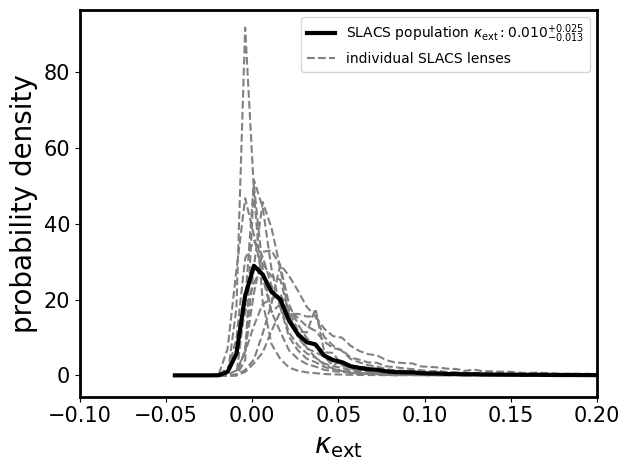

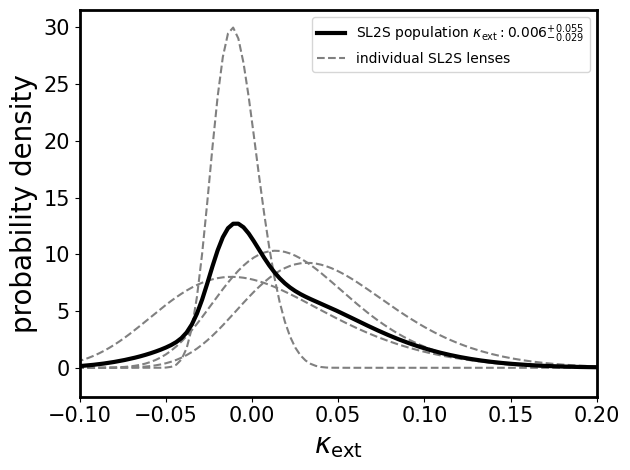

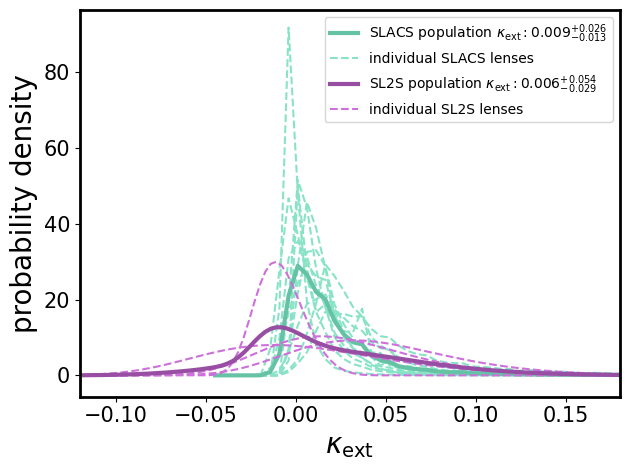

In [15]:
slacs_selected = name_list_slacs_ifu_quality

slacs_kappa_ext_list, slacs_kappa_ext_mean = kappa_distribution(slacs_selected, sample_name='SLACS')

sl2s_kappa_ext_list, sl2s_kappa_ext_mean = kappa_distribution(name_list_sl2s_quality_all, sample_name='SL2S')


def plot_kappa_ext():

    fig = plt.figure()

    _,_ = kappa_distribution(slacs_selected, sample_name='SLACS', fig = fig, color_individual="#88e3c6", color_pop=color_kcwi)

    _,_ = kappa_distribution(name_list_sl2s_quality_all, sample_name='SL2S', fig=fig, color_pop=color_sl2s, color_individual="#cd70db")

    ax = fig.gca()
    ax.set_xlim([-0.12, 0.18])
    # fig.savefig('./kappa_ext_slacs_sl2s.pdf', bbox_inches='tight')

    plt.show()

plot_kappa_ext()


In [16]:
def NoverRvskappa_mean(name_list, sample_name):
    name_all, kappa_mean_all= kappa_distribution(name_list, sample_name, plot=False)
    NoverR_plot = []
    kappa_plot = []
    for name in name_list:
        NoverR = NoverRmed(name, sample_name)
        NoverR_plot.append(NoverR)
        pos = name_all.index(name)
        kappa_mean = kappa_mean_all[pos]
        kappa_plot.append(kappa_mean)
        print(name+' kappa_ext_mean = {:.5f}, NoverRmed = {:.3f}' .format(kappa_mean, NoverR))

    plt.plot(NoverR_plot, kappa_plot, 'o')
    plt.title('{} lens sample: {} lenses' .format(sample_name, len(name_list)))
    plt.xlabel(r'$\zeta_{1/r}$')
    plt.ylabel(r'$\kappa_{\rm ext}$ mean')
    plt.show()
    

SL2SJ0226-0420 kappa_ext_mean = -0.01023, NoverRmed = 1.021
SL2SJ0855-0147 kappa_ext_mean = 0.00211, NoverRmed = 1.098
SL2SJ0904-0059 kappa_ext_mean = 0.02435, NoverRmed = 1.228
SL2SJ2221+0115 kappa_ext_mean = 0.04438, NoverRmed = 1.407


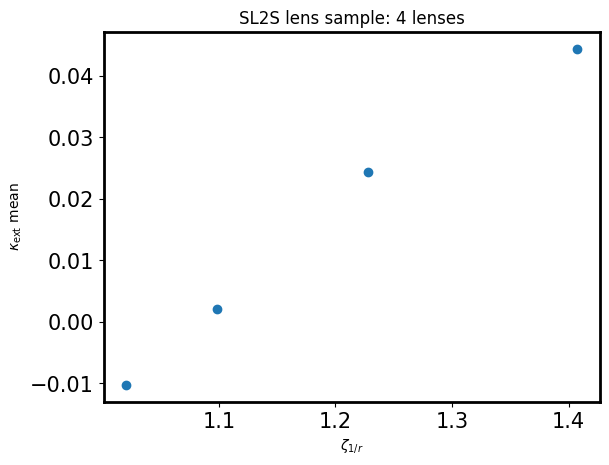

In [17]:
NoverRvskappa_mean(name_list_sl2s_quality_all, 'SL2S')

SDSSJ0029-0055 kappa_ext_mean = 0.00212, NoverRmed = 1.139
SDSSJ0037-0942 kappa_ext_mean = 0.01751, NoverRmed = 1.603
SDSSJ1112+0826 kappa_ext_mean = 0.04602, NoverRmed = 1.962
SDSSJ1204+0358 kappa_ext_mean = 0.02913, NoverRmed = 1.885
SDSSJ1250+0523 kappa_ext_mean = 0.03041, NoverRmed = 1.567
SDSSJ1306+0600 kappa_ext_mean = 0.01521, NoverRmed = 1.790
SDSSJ1402+6321 kappa_ext_mean = 0.01125, NoverRmed = 1.733
SDSSJ1531-0105 kappa_ext_mean = 0.01637, NoverRmed = 1.363
SDSSJ1621+3931 kappa_ext_mean = -0.00248, NoverRmed = 0.969
SDSSJ1627-0053 kappa_ext_mean = 0.00869, NoverRmed = 1.468
SDSSJ1630+4520 kappa_ext_mean = 0.00983, NoverRmed = 1.293


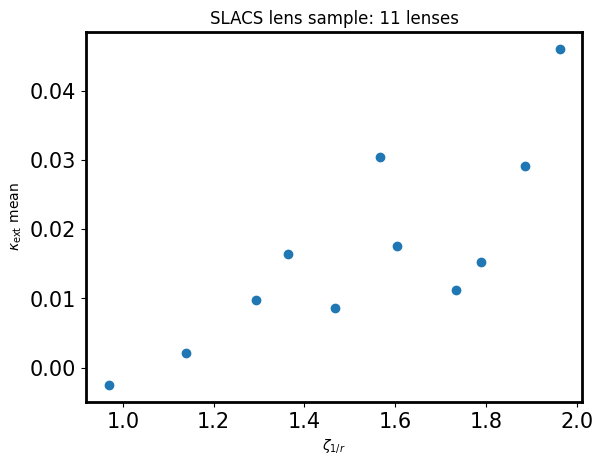

In [18]:
NoverRvskappa_mean(slacs_selected, 'SLACS')

## Print statements for making latex table

In [19]:
def sample_sigma_v_err(name_list, sample_name):

    if sample_name == 'SLACS':
        file_name = file_name_slacs
    elif sample_name == 'SL2S':
        file_name = file_name_sl2s
    elif sample_name == 'SL2S_new_data':
        file_name = file_name_sl2s_new_data
    elif sample_name == 'TDCOSMO':
        file_name = file_name_tdcosmo_yaml

    sigma_v_err_list = []
    lens_name = []

    if sample_name in ['SLACS', 'SL2S', 'SL2S_new_data']:
        with open(file_name, newline='') as myFile:
            reader = csv.DictReader(myFile)
            for row in reader:
                name = row['name']
                if name in name_list:
                    _, sigma_v_err = vel_disp(row, sample_name=sample_name)
                    sigma_v_err_list.append(sigma_v_err)
                    lens_name.append(name)
    elif sample_name == 'TDCOSMO':
        with open(file_name, 'r') as myFile:
            tdcosmo_yaml = yaml.safe_load(myFile)
            for name in tdcosmo_yaml.keys():
                row = tdcosmo_yaml[name]
                row['name'] = name
                if name in name_list:
                    _, sigma_v_err = vel_disp(row, sample_name=sample_name)
                    sigma_v_err_list.append(sigma_v_err)
                    lens_name.append(name)
                
    return dict(zip(lens_name, sigma_v_err_list))


In [20]:
# read out gamma_pl uncertainty (statistical and systematic, added in quadrature)
_, _, _, _, gamma_err, gamma_err_name_list = gamma_distribution(file_name_tdcosmo_yaml, name_list_tdcosmo, yaml_file=True)
gamma_err_dict = dict(zip(gamma_err_name_list, gamma_err))
sigma_v_err_dict = sample_sigma_v_err(name_list_tdcosmo, "TDCOSMO")

def sort_ra(name_list, param):

    ra_list = np.array([int(re.findall(r'\d+', name)[0]) for name in name_list])
    sort_indices = np.argsort(ra_list)
    name_list_sorted = [name_list[i] for i in sort_indices]
    param_sorted = [param[i] for i in sort_indices]
    return name_list_sorted, param_sorted 

name_list_tdcosmo, tdcosmo_sample = sort_ra(name_list_tdcosmo, tdcosmo_sample)


for name, param in zip(name_list_tdcosmo, tdcosmo_sample):

    str_list = []
    str_list.append(str(name).replace('-', '$-$').replace('+', '$+$') + ' & ')
    str_list.append(f'{param[0]:.3f}' + ' & ')
    str_list.append(f'{param[1]:.3f}' + ' & ')
    str_list.append(f'{param[2]:.1f}' + '$\pm$' + f"{sigma_v_err_dict[name]:.1f}" + ' & ')
    str_list.append(f"{param[3]:.3f}" + ' & ')
    str_list.append(f'{param[4]:.2f}' + ' & ')
    str_list.append(f'{param[6]:.2f}' + '$\pm$' + f"{gamma_err_dict[name]:.2f}" + ' & ')
    str_list.append(f'{param[9]:.2f}' + ' & ')
    str_list.append('' + ' \\\\ \n')
    str_list = ''.join(str_list)
    print(str_list)


DES0408$-$5354 & 0.597 & 2.375 & 242.3$\pm$12.2 & 1.940 & 1.92 & 1.90$\pm$0.03 & 0.80 &  \\ 

HE0435$-$1223 & 0.455 & 1.693 & 226.6$\pm$5.8 & 1.800 & 1.22 & 1.93$\pm$0.02 & 0.93 &  \\ 

PG1115$+$080 & 0.311 & 1.722 & 235.7$\pm$6.6 & 0.450 & 1.08 & 2.17$\pm$0.05 & 0.95 &  \\ 

RXJ1131$-$1231 & 0.295 & 0.654 & 303.0$\pm$8.3 & 1.910 & 1.63 & 1.95$\pm$0.05 & 0.94 &  \\ 

SDSS1206$+$4332 & 0.745 & 1.789 & 290.5$\pm$9.5 & 0.290 & 1.25 & 1.95$\pm$0.05 & 0.85 &  \\ 

B1608$+$656 & 0.630 & 1.394 & 305.3$\pm$11.0 & 0.590 & 0.81 & 2.08$\pm$0.03 & 1.00 &  \\ 

WFI2033$-$4723 & 0.657 & 1.662 & 210.7$\pm$10.5 & 1.970 & 0.94 & 1.95$\pm$0.02 & 0.83 &  \\ 

WGD2038$-$4008 & 0.228 & 0.777 & 254.7$\pm$16.3 & 2.223 & 1.38 & 2.30$\pm$0.02 & 0.85 &  \\ 



In [21]:
_, _, _, _, gamma_err, gamma_err_name_list = gamma_distribution(file_name_slacs, name_list_slacs_ifu_quality)
gamma_err_dict = dict(zip(gamma_err_name_list, gamma_err))
sigma_v_err_dict = sample_sigma_v_err(name_list_slacs_ifu_quality, "SLACS")

name_list_slacs_ifu_quality, slacs_ifu_sample_quality = sort_ra(name_list_slacs_ifu_quality, slacs_ifu_sample_quality)

for name, param in zip(name_list_slacs_ifu_quality, slacs_ifu_sample_quality):

    str_list = []
    str_list.append(str(name).replace('-', '$-$').replace('+', '$+$') + ' & ')
    str_list.append(f'{param[0]:.3f}' + ' & ')
    str_list.append(f'{param[1]:.3f}' + ' & ')
    str_list.append(f'{param[2]:.1f}' + '$\pm$' + f"{sigma_v_err_dict[name]:.1f}" + ' & ')
    str_list.append(f"{param[3]:.3f}" + ' & ')
    str_list.append(f'{param[4]:.2f}' + ' & ')
    str_list.append(f'{param[6]:.2f}' + '$\pm$' + f"{gamma_err_dict[name]:.2f}" + ' & ')
    str_list.append(f'{param[9]:.2f}' + ' & ')
    str_list.append(f'{param[10]:.1f}' + ' \\\\ \n')
    str_list = ''.join(str_list)
    print(str_list)



SDSSJ0029$-$0055 & 0.227 & 0.931 & 208.2$\pm$2.8 & 2.386 & 0.94 & 2.69$\pm$0.25 & 0.94 & 128.3 \\ 

SDSSJ0037$-$0942 & 0.195 & 0.632 & 278.8$\pm$2.9 & 3.334 & 1.48 & 2.38$\pm$0.11 & 0.87 & 240.1 \\ 

SDSSJ1112$+$0826 & 0.273 & 0.629 & 276.4$\pm$3.4 & 1.623 & 1.50 & 1.92$\pm$0.18 & 0.76 & 254.9 \\ 

SDSSJ1204$+$0358 & 0.164 & 0.631 & 260.2$\pm$2.9 & 1.544 & 1.29 & 2.02$\pm$0.05 & 0.99 & 204.9 \\ 

SDSSJ1250$+$0523 & 0.232 & 0.795 & 243.4$\pm$2.6 & 1.748 & 1.12 & 2.18$\pm$0.09 & 0.92 & 225.1 \\ 

SDSSJ1306$+$0600 & 0.173 & 0.472 & 229.7$\pm$2.8 & 2.369 & 1.31 & 1.97$\pm$0.07 & 0.88 & 121.1 \\ 

SDSSJ1402$+$6321 & 0.205 & 0.481 & 282.6$\pm$2.9 & 2.720 & 1.37 & 1.57$\pm$0.30 & 0.76 & 56.5 \\ 

SDSSJ1531$-$0105 & 0.160 & 0.744 & 275.8$\pm$3.6 & 3.416 & 1.71 & 2.07$\pm$0.26 & 0.85 & 118.7 \\ 

SDSSJ1621$+$3931 & 0.245 & 0.602 & 262.7$\pm$3.5 & 2.402 & 1.27 & 2.02$\pm$0.07 & 0.87 & 265.2 \\ 

SDSSJ1627$-$0053 & 0.208 & 0.524 & 263.5$\pm$3.3 & 2.981 & 1.22 & 1.93$\pm$0.14 & 0.92 & 185.6 \\ 

S

In [22]:
_, _, _, _, gamma_err, gamma_err_name_list = gamma_distribution(file_name_sl2s_new_data, name_list_sl2s_new_quality)
gamma_err_dict_new = dict(zip(gamma_err_name_list, gamma_err))

sigma_v_err_dict_new = sample_sigma_v_err(name_list_sl2s_new_quality, "SL2S_new_data")

if bool(name_list_sl2s_quality): # if there are selected lenses from the dinos1 dataset

    _, _, _, _, gamma_err, gamma_err_name_list = gamma_distribution(file_name_sl2s, name_list_sl2s_quality)
    gamma_err_dict = dict(zip(gamma_err_name_list, gamma_err))

    gamma_err_dict_new.update(gamma_err_dict)

    sigma_v_err_dict = sample_sigma_v_err(name_list_sl2s_quality, 'SL2S')

    sigma_v_err_dict_new.update(sigma_v_err_dict)


name_list_sl2s_quality_all, sl2s_sample_quality_all = sort_ra(name_list_sl2s_quality_all, sl2s_sample_quality_all)


for name, param in zip(name_list_sl2s_quality_all, sl2s_sample_quality_all):

    str_list = []
    str_list.append(str(name).replace('-', '$-$').replace('+', '$+$') + ' & ')
    str_list.append(f'{param[0]:.3f}' + ' & ')
    str_list.append(f'{param[1]:.3f}' + ' & ')
    str_list.append(f'{param[2]:.1f}' + '$\pm$' + f"{sigma_v_err_dict_new[name]:.1f}" + ' & ')
    str_list.append(f"{param[3]:.3f}" + ' & ')
    str_list.append(f'{param[4]:.2f}' + ' & ')
    str_list.append(f'{param[6]:.2f}' + '$\pm$' + f"{gamma_err_dict_new[name]:.2f}" + ' & ')
    str_list.append(f'{param[9]:.2f}' + ' & ')
    str_list.append(f'{param[10]:.1f}' + ' \\\\ \n')
    str_list = ''.join(str_list)
    print(str_list)



SL2SJ0226$-$0420 & 0.494 & 1.230 & 310.0$\pm$14.0 & 0.389 & 1.15 & 2.05$\pm$0.15 & 0.73 & 224.1 \\ 

SL2SJ0855$-$0147 & 0.365 & 3.390 & 196.0$\pm$11.0 & 0.470 & 0.96 & 2.25$\pm$0.11 & 0.91 & 177.5 \\ 

SL2SJ0904$-$0059 & 0.611 & 2.360 & 232.0$\pm$9.0 & 0.713 & 1.41 & 1.98$\pm$0.15 & 0.81 & 319.7 \\ 

SL2SJ2221$+$0115 & 0.325 & 2.350 & 277.0$\pm$13.0 & 0.532 & 1.27 & 2.14$\pm$0.13 & 0.77 & 195.3 \\ 

